In [1]:
# Import Library

import mne
import numpy as np
from scipy.stats import skew, kurtosis
from mne.time_frequency import psd_array_welch
import gc
import psutil

def show_ram():
    ram = psutil.virtual_memory()
    print(f"Available RAM: {ram.available / 1e9:.1f} GB / {ram.total / 1e9:.1f} GB")

show_ram()

Available RAM: 7.4 GB / 8.2 GB


In [2]:
# Import raw data (.fif)

raw = mne.io.read_raw_fif(
    "sub10_sess1_50_ica_eeg.fif",
    preload=True
)

print(raw)

Opening raw data file sub10_sess1_50_ica_eeg.fif...
    Range : 0 ... 4326399 =      0.000 ...  4224.999 secs
Ready.
Opening raw data file /home/cindy/BHSFinal/sub10_sess1_50_ica_eeg-1.fif...
    Range : 4326400 ... 4958827 =   4225.000 ...  4842.604 secs
Ready.
Reading 0 ... 4958827  =      0.000 ...  4842.604 secs...
<Raw | sub10_sess1_50_ica_eeg.fif, 124 x 4958828 (4842.6 s), ~4.58 GiB, data loaded>


In [3]:
# check events and event id
events, event_id = mne.events_from_annotations(raw)

Used Annotations descriptions: [np.str_('0, Imagination_a_flower_high_10###my_stream_name'), np.str_('0, Imagination_a_flower_high_11###my_stream_name'), np.str_('0, Imagination_a_flower_high_17###my_stream_name'), np.str_('0, Imagination_a_flower_high_23###my_stream_name'), np.str_('0, Imagination_a_flower_high_4###my_stream_name'), np.str_('0, Imagination_a_flower_high_5###my_stream_name'), np.str_('0, Imagination_a_flower_low_10###my_stream_name'), np.str_('0, Imagination_a_flower_low_13###my_stream_name'), np.str_('0, Imagination_a_flower_low_17###my_stream_name'), np.str_('0, Imagination_a_flower_low_23###my_stream_name'), np.str_('0, Imagination_a_flower_low_25###my_stream_name'), np.str_('0, Imagination_a_flower_low_5###my_stream_name'), np.str_('0, Imagination_a_flower_normal_10###my_stream_name'), np.str_('0, Imagination_a_flower_normal_11###my_stream_name'), np.str_('0, Imagination_a_flower_normal_12###my_stream_name'), np.str_('0, Imagination_a_flower_normal_16###my_stream_n

In [4]:
# clean the name so that it only countain "perception_modalities_unique code"

clean_event_id = {}

for k, v in event_id.items():
    clean_name = k.split(", ")[-1]      # remove "0, "
    clean_name = clean_name.replace("###my_stream_name", "")
    clean_event_id[clean_name] = v

# print(clean_event_id)

In [5]:
# Create modalities group

# Image
image_events = [
    k for k in clean_event_id.keys()
    if k.startswith("Perception_image")
]


# Text
text_events = [
    k for k in clean_event_id.keys()
    if k.startswith("Perception_t")
]


# Audio
audio_events = [
    k for k in clean_event_id.keys()
    if k.startswith("Perceptiona")
]

print("Image:", len(image_events))
print("Text:", len(text_events))
print("Audio:", len(audio_events))

print("Image:", image_events)
print("Text:", text_events)
print("Audio:", audio_events)

Image: 9
Text: 15
Audio: 75
Image: ['Perception_image_flower_c', 'Perception_image_flower_m', 'Perception_image_flower_s', 'Perception_image_guitar_c', 'Perception_image_guitar_m', 'Perception_image_guitar_s', 'Perception_image_penguin_c', 'Perception_image_penguin_m', 'Perception_image_penguin_s']
Text: ['Perception_t_flower_1', 'Perception_t_flower_2', 'Perception_t_flower_3', 'Perception_t_flower_4', 'Perception_t_flower_5', 'Perception_t_guitar_1', 'Perception_t_guitar_2', 'Perception_t_guitar_3', 'Perception_t_guitar_4', 'Perception_t_guitar_5', 'Perception_t_penguin_1', 'Perception_t_penguin_2', 'Perception_t_penguin_3', 'Perception_t_penguin_4', 'Perception_t_penguin_5']
Audio: ['Perceptiona_flower_high_10', 'Perceptiona_flower_high_11', 'Perceptiona_flower_high_17', 'Perceptiona_flower_high_23', 'Perceptiona_flower_high_4', 'Perceptiona_flower_high_5', 'Perceptiona_flower_low_10', 'Perceptiona_flower_low_13', 'Perceptiona_flower_low_17', 'Perceptiona_flower_low_23', 'Perception

In [6]:
# Convert the new groups into event_id

image_event_id = {k: clean_event_id[k] for k in image_events}
text_event_id  = {k: clean_event_id[k] for k in text_events}
audio_event_id = {k: clean_event_id[k] for k in audio_events}

print("Image: ", image_event_id)
print("Text: ", text_event_id)
print("Audio: ", audio_event_id)

Image:  {'Perception_image_flower_c': 101, 'Perception_image_flower_m': 102, 'Perception_image_flower_s': 103, 'Perception_image_guitar_c': 104, 'Perception_image_guitar_m': 105, 'Perception_image_guitar_s': 106, 'Perception_image_penguin_c': 107, 'Perception_image_penguin_m': 108, 'Perception_image_penguin_s': 109}
Text:  {'Perception_t_flower_1': 110, 'Perception_t_flower_2': 111, 'Perception_t_flower_3': 112, 'Perception_t_flower_4': 113, 'Perception_t_flower_5': 114, 'Perception_t_guitar_1': 115, 'Perception_t_guitar_2': 116, 'Perception_t_guitar_3': 117, 'Perception_t_guitar_4': 118, 'Perception_t_guitar_5': 119, 'Perception_t_penguin_1': 120, 'Perception_t_penguin_2': 121, 'Perception_t_penguin_3': 122, 'Perception_t_penguin_4': 123, 'Perception_t_penguin_5': 124}
Audio:  {'Perceptiona_flower_high_10': 125, 'Perceptiona_flower_high_11': 126, 'Perceptiona_flower_high_17': 127, 'Perceptiona_flower_high_23': 128, 'Perceptiona_flower_high_4': 129, 'Perceptiona_flower_high_5': 130, 'P

In [7]:
# Combine all event_id
all_event_id = {}

all_event_id.update(image_event_id)
all_event_id.update(text_event_id)
all_event_id.update(audio_event_id)

print(all_event_id)

{'Perception_image_flower_c': 101, 'Perception_image_flower_m': 102, 'Perception_image_flower_s': 103, 'Perception_image_guitar_c': 104, 'Perception_image_guitar_m': 105, 'Perception_image_guitar_s': 106, 'Perception_image_penguin_c': 107, 'Perception_image_penguin_m': 108, 'Perception_image_penguin_s': 109, 'Perception_t_flower_1': 110, 'Perception_t_flower_2': 111, 'Perception_t_flower_3': 112, 'Perception_t_flower_4': 113, 'Perception_t_flower_5': 114, 'Perception_t_guitar_1': 115, 'Perception_t_guitar_2': 116, 'Perception_t_guitar_3': 117, 'Perception_t_guitar_4': 118, 'Perception_t_guitar_5': 119, 'Perception_t_penguin_1': 120, 'Perception_t_penguin_2': 121, 'Perception_t_penguin_3': 122, 'Perception_t_penguin_4': 123, 'Perception_t_penguin_5': 124, 'Perceptiona_flower_high_10': 125, 'Perceptiona_flower_high_11': 126, 'Perceptiona_flower_high_17': 127, 'Perceptiona_flower_high_23': 128, 'Perceptiona_flower_high_4': 129, 'Perceptiona_flower_high_5': 130, 'Perceptiona_flower_low_10'

In [8]:
# Create epoch 

epochs = mne.Epochs(
    raw,
    events,
    event_id=all_event_id,
    tmin=0,
    tmax=2.0,
    baseline=None,
    preload=True
)

# Free raw
del raw
gc.collect()
print("raw deleted")
show_ram()

Not setting metadata
450 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 450 events and 2049 original time points ...
0 bad epochs dropped
raw deleted
Available RAM: 6.5 GB / 8.2 GB


In [9]:
# split epochs by modality

epochs_text = epochs[text_events]
epochs_image = epochs[image_events]
epochs_audio = epochs[audio_events]

In [11]:
# Labels

import numpy as np

y_text  = np.zeros(len(epochs_text))          # 0 = text
y_image = np.ones(len(epochs_image))          # 1 = image
y_audio = np.full(len(epochs_audio), 2)       # 2 = audio

In [12]:
# Combine epochs

all_epochs = mne.concatenate_epochs([
    epochs_text,    # must match y order
    epochs_image,
    epochs_audio
])
y = np.concatenate([y_text, y_image, y_audio])

/tmp/ipykernel_1010/1489661059.py:3: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  all_epochs = mne.concatenate_epochs([


Not setting metadata
450 matching events found
No baseline correction applied


In [13]:
# Free raw

del epochs, epochs_text, epochs_image, epochs_audio
gc.collect()
print("Freed. Only all_epochs remains.")
show_ram()

Freed. Only all_epochs remains.
Available RAM: 6.5 GB / 8.2 GB


In [ ]:
###########################################################
# PSD Full spectrum features (X_psd)
###########################################################

In [30]:
BATCH = 50
psds_list = []

for start in range(0, len(all_epochs), BATCH):
    end   = min(start + BATCH, len(all_epochs))
    batch = all_epochs[start:end].get_data()
    psds, freqs = psd_array_welch(batch, sfreq=all_epochs.info['sfreq'],
                                   fmin=1, fmax=40,
                                   n_jobs=1, verbose=False)
    psds_list.append(psds)
    del batch
    gc.collect()
    print(f"PSD: {start}–{end-1}")

X_psd_full = np.concatenate(psds_list, axis=0)
X_psd      = X_psd_full.reshape(X_psd_full.shape[0], -1)  # (450, n_ch * n_freqs)
del psds_list, X_psd_full
gc.collect()
print(f"PSD features shape: {X_psd.shape}")
show_ram()

PSD: 0–49
PSD: 50–99
PSD: 100–149
PSD: 150–199
PSD: 200–249
PSD: 250–299
PSD: 300–349
PSD: 350–399
PSD: 400–449
PSD features shape: (450, 1240)
Available RAM: 6.3 GB / 8.2 GB


In [22]:
# to check the full shape before flatenning
print(X_psd_full.shape)

# after flatening is 450, 1240
# 450 trials, 124 channels, 10 frequency bins

(450, 124, 10)


In [28]:
print(freqs)
# the 10 bins

[ 4.  8. 12. 16. 20. 24. 28. 32. 36. 40.]


In [29]:
# the ori data freq
print(all_epochs.info['sfreq'])

1024.0


In [ ]:
###########################################################
# Frequency band power features (X_band)
###########################################################

In [15]:
# EEG frequency bands
bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta' : (13, 30),
    'gamma': (30, 40)
}

BATCH = 50
band_list = []

for start in range(0, len(all_epochs), BATCH):
    end   = min(start + BATCH, len(all_epochs))
    batch = all_epochs[start:end].get_data()

    # Compute PSD for this batch
    psds, freqs = psd_array_welch(batch, sfreq=all_epochs.info['sfreq'],
                                   fmin=1, fmax=40,
                                   n_jobs=1, verbose=False)
    # psds shape: (batch, n_channels, n_freqs)

    batch_bands = []
    for band_name, (fmin, fmax) in bands.items():
        # Find frequency indices for this band
        idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        # Mean power in this band per channel
        band_power = np.mean(psds[:, :, idx], axis=2)  # (batch, n_channels)
        batch_bands.append(band_power)

    # Stack bands → (batch, n_channels, n_bands) → flatten → (batch, n_channels * n_bands)
    batch_feat = np.stack(batch_bands, axis=2)
    band_list.append(batch_feat.reshape(end - start, -1))

    del batch, psds, batch_bands, batch_feat
    gc.collect()
    print(f"Band power: {start}–{end-1}")

X_band = np.concatenate(band_list, axis=0)
del band_list
gc.collect()
print(f"Band power features shape: {X_band.shape}")
# expect: (450, n_channels * 5)
show_ram()

Band power: 0–49
Band power: 50–99
Band power: 100–149
Band power: 150–199
Band power: 200–249
Band power: 250–299
Band power: 300–349
Band power: 350–399
Band power: 400–449
Band power features shape: (450, 620)
Available RAM: 6.4 GB / 8.2 GB


In [ ]:
###########################################################
# Time domain features (X_time)
###########################################################

In [16]:
BATCH = 30
time_list = []

for start in range(0, len(all_epochs), BATCH):
    end     = min(start + BATCH, len(all_epochs))
    batch   = all_epochs[start:end].get_data()
    n_times = batch.shape[2]

    mean    = np.mean(batch, axis=2)
    var     = np.var(batch, axis=2)
    std     = np.std(batch, axis=2)
    sk      = skew(batch, axis=2)
    kurt    = kurtosis(batch, axis=2)
    ch_min  = np.min(batch, axis=2)
    ch_max  = np.max(batch, axis=2)
    ptp     = np.ptp(batch, axis=2)
    rms     = np.sqrt(np.mean(batch**2, axis=2))
    zcr     = np.sum(np.diff(np.sign(batch), axis=2) != 0, axis=2) / n_times

    feats   = np.stack([mean, var, std, sk, kurt,
                        ch_min, ch_max, ptp, rms, zcr], axis=2)
    time_list.append(feats.reshape(end - start, -1))

    del batch, mean, var, std, sk, kurt
    del ch_min, ch_max, ptp, rms, zcr, feats
    gc.collect()
    print(f"Time: {start}–{end-1}")

X_time = np.concatenate(time_list, axis=0)
del time_list
gc.collect()
print(f"Time domain features shape: {X_time.shape}")
show_ram()

Time: 0–29
Time: 30–59
Time: 60–89
Time: 90–119
Time: 120–149
Time: 150–179
Time: 180–209
Time: 210–239
Time: 240–269
Time: 270–299
Time: 300–329
Time: 330–359
Time: 360–389
Time: 390–419
Time: 420–449
Time domain features shape: (450, 1240)
Available RAM: 6.4 GB / 8.2 GB


In [17]:
# Build 3 feature sets

# Feature set 1 — PSD only 
X_freq = X_psd.copy()

# Feature set 2 — PSD + Time domain 
X_freq_time = np.hstack([X_psd, X_time])

# Feature set 3 — PSD + Band power + Time domain 
X_freq_band_time = np.hstack([X_psd, X_band, X_time])

print(f"X_freq shape:           {X_freq.shape}")
print(f"X_freq_time shape:      {X_freq_time.shape}")
print(f"X_freq_band_time shape: {X_freq_band_time.shape}")
show_ram()

X_freq shape:           (450, 1240)
X_freq_time shape:      (450, 2480)
X_freq_band_time shape: (450, 3100)
Available RAM: 6.4 GB / 8.2 GB


In [18]:
# SVM Pipeline function

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def run_svm(X_input, y, label, k=150):
    print(f"\n{'='*50}")
    print(f"Feature set: {label}")
    print(f"{'='*50}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_input, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ('scaler',   StandardScaler()),
        ('selector', SelectKBest(f_classif, k=k)),
        ('svm',      SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print()
    print(classification_report(y_test, y_pred,
                                 target_names=['Text', 'Image', 'Audio']))

    # CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_input, y, cv=cv, scoring='accuracy', n_jobs=1)
    print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"Per fold:    {scores.round(4)}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Text', 'Image', 'Audio'],
                yticklabels=['Text', 'Image', 'Audio'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix — {label}')
    plt.show()

    return scores.mean()


Feature set: PSD only
Test Accuracy: 0.5667

              precision    recall  f1-score   support

        Text       0.56      0.60      0.58        30
       Image       0.57      0.57      0.57        30
       Audio       0.57      0.53      0.55        30

    accuracy                           0.57        90
   macro avg       0.57      0.57      0.57        90
weighted avg       0.57      0.57      0.57        90

CV Accuracy: 0.5267 ± 0.0413
Per fold:    [0.5333 0.5444 0.4667 0.5    0.5889]


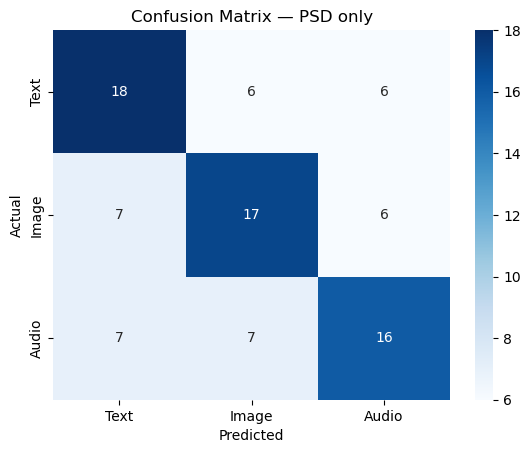


Feature set: PSD + Time
Test Accuracy: 0.6111

              precision    recall  f1-score   support

        Text       0.61      0.57      0.59        30
       Image       0.59      0.63      0.61        30
       Audio       0.63      0.63      0.63        30

    accuracy                           0.61        90
   macro avg       0.61      0.61      0.61        90
weighted avg       0.61      0.61      0.61        90

CV Accuracy: 0.5422 ± 0.0479
Per fold:    [0.5222 0.5444 0.5111 0.5    0.6333]


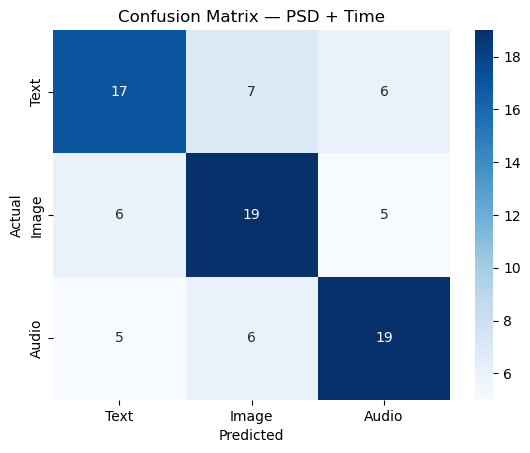


Feature set: PSD + Band + Time
Test Accuracy: 0.5889

              precision    recall  f1-score   support

        Text       0.61      0.57      0.59        30
       Image       0.56      0.67      0.61        30
       Audio       0.62      0.53      0.57        30

    accuracy                           0.59        90
   macro avg       0.59      0.59      0.59        90
weighted avg       0.59      0.59      0.59        90

CV Accuracy: 0.5200 ± 0.0634
Per fold:    [0.4889 0.5333 0.4444 0.5    0.6333]


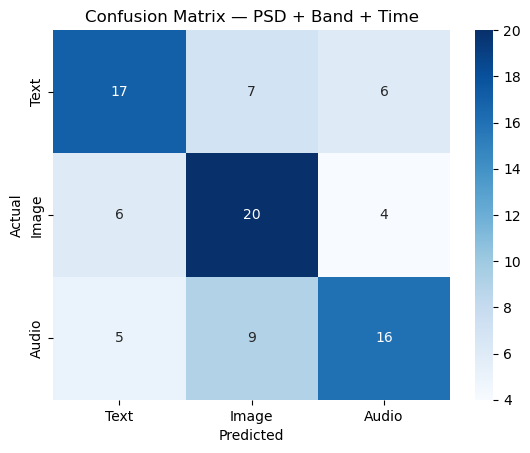


SUMMARY
PSD only:             0.5267
PSD + Time:           0.5422
PSD + Band + Time:    0.5200


In [19]:
# Run all 3 and compare

acc1 = run_svm(X_freq,           y, label='PSD only')
acc2 = run_svm(X_freq_time,      y, label='PSD + Time')
acc3 = run_svm(X_freq_band_time, y, label='PSD + Band + Time')

print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"{'='*50}")
print(f"PSD only:             {acc1:.4f}")
print(f"PSD + Time:           {acc2:.4f}")
print(f"PSD + Band + Time:    {acc3:.4f}")